In [1]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

# Paths
data_path = r"C:\visual_searh_project\data\raw_data\Stanford_Online_Products\Stanford_Online_Products"
train_file = os.path.join(data_path, "Ebay_train.txt")
test_file  = os.path.join(data_path, "Ebay_test.txt")

# Verify GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
train_df = pd.read_csv(train_file, sep=' ', header=0)
test_df  = pd.read_csv(test_file,  sep=' ', header=0)

print("Train shape:", train_df.shape)
print("Test shape: ", test_df.shape)
print(train_df.head())

Train shape: (59551, 4)
Test shape:  (60502, 4)
   image_id  class_id  super_class_id                              path
0         1         1               1  bicycle_final/111085122871_0.JPG
1         2         1               1  bicycle_final/111085122871_1.JPG
2         3         1               1  bicycle_final/111085122871_2.JPG
3         4         1               1  bicycle_final/111085122871_3.JPG
4         5         1               1  bicycle_final/111085122871_4.JPG


In [3]:
class SOPDataset(Dataset):
    def __init__(self, df, data_path, transform=None):
        self.df = df.reset_index(drop=True)
        self.data_path = data_path
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.data_path, row['path'])
        
        try:
            img = Image.open(img_path).convert('RGB')
        except:
            img = Image.new('RGB', (224, 224))
        
        if self.transform:
            img = self.transform(img)
            
        label = int(row['class_id'])
        return img, label

In [4]:
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [5]:
train_dataset = SOPDataset(train_df, data_path, transform)
test_dataset  = SOPDataset(test_df,  data_path, transform)

train_loader = DataLoader(train_dataset, batch_size=64, 
                          shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=64, 
                          shuffle=False, num_workers=0)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches:  {len(test_loader)}")

Train batches: 931
Test batches:  946


In [6]:
# Load pretrained ResNet50
resnet = models.resnet50(pretrained=True)

# Remove final FC layer — we want 2048-dim embeddings
resnet = nn.Sequential(*list(resnet.children())[:-1])
resnet = resnet.to(device)
resnet.eval()

print("ResNet50 loaded — final FC layer removed")
print("Output embedding dimension: 2048")

C:\Users\UTKARSH\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\UTKARSH\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\UTKARSH/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:17<00:00, 5.93MB/s]


ResNet50 loaded — final FC layer removed
Output embedding dimension: 2048


In [7]:
def extract_embeddings(loader, model, device):
    all_embeddings = []
    all_labels = []
    
    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc="Extracting embeddings"):
            imgs = imgs.to(device)
            
            # Forward pass
            embeddings = model(imgs)
            
            # Flatten from (batch, 2048, 1, 1) to (batch, 2048)
            embeddings = embeddings.squeeze(-1).squeeze(-1)
            
            all_embeddings.append(embeddings.cpu().numpy())
            all_labels.append(labels.numpy())
    
    all_embeddings = np.vstack(all_embeddings)
    all_labels     = np.concatenate(all_labels)
    
    return all_embeddings, all_labels

In [8]:
print("Extracting TRAIN embeddings...")
train_embeddings, train_labels = extract_embeddings(train_loader, resnet, device)

print("Extracting TEST embeddings...")
test_embeddings, test_labels = extract_embeddings(test_loader, resnet, device)

print(f"\nTrain embeddings shape: {train_embeddings.shape}")
print(f"Test embeddings shape:  {test_embeddings.shape}")

Extracting TRAIN embeddings...


Extracting embeddings: 100%|██████████| 931/931 [16:16<00:00,  1.05s/it]


Extracting TEST embeddings...


Extracting embeddings: 100%|██████████| 946/946 [16:51<00:00,  1.07s/it]



Train embeddings shape: (59551, 2048)
Test embeddings shape:  (60502, 2048)


In [9]:
save_path = r"C:\visual_searh_project\data\processed"
os.makedirs(save_path, exist_ok=True)

np.save(os.path.join(save_path, "train_embeddings.npy"), train_embeddings)
np.save(os.path.join(save_path, "train_labels.npy"),     train_labels)
np.save(os.path.join(save_path, "test_embeddings.npy"),  test_embeddings)
np.save(os.path.join(save_path, "test_labels.npy"),      test_labels)

print("All embeddings saved successfully.")

All embeddings saved successfully.


In [14]:
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity

def recall_at_k(test_emb, test_labels, k=10):
    # Normalize
    test_norm = normalize(test_emb)
    
    correct = 0
    batch_size = 200
    
    for i in tqdm(range(0, len(test_norm), batch_size),
                  desc=f"Recall@{k}"):
        batch = test_norm[i:i+batch_size]
        sims  = cosine_similarity(batch, test_norm)
        
        for j in range(len(batch)):
            # Set self-similarity to -1 so it's never top-1
            sims[j][i+j] = -1
            
            top_k_idx       = np.argsort(-sims[j])[:k]
            query_label     = test_labels[i+j]
            retrieved_labels = test_labels[top_k_idx]
            
            if query_label in retrieved_labels:
                correct += 1
    
    return correct / len(test_norm)

In [15]:
print("Measuring corrected Recall@K scores...")
print("(Takes 10-15 mins on CPU)")

r1  = recall_at_k(test_embeddings, test_labels, k=1)
r5  = recall_at_k(test_embeddings, test_labels, k=5)
r10 = recall_at_k(test_embeddings, test_labels, k=10)

print(f"\n===== BASELINE RESULTS (ResNet50) =====")
print(f"Recall@1  : {r1*100:.2f}%")
print(f"Recall@5  : {r5*100:.2f}%")
print(f"Recall@10 : {r10*100:.2f}%")
print("========================================")

Measuring corrected Recall@K scores...
(Takes 10-15 mins on CPU)


Recall@10: 100%|██████████| 303/303 [03:27<00:00,  1.46it/s]


===== BASELINE RESULTS (ResNet50) =====
Recall@1  : 53.79%
Recall@5  : 65.48%
Recall@10 : 69.88%


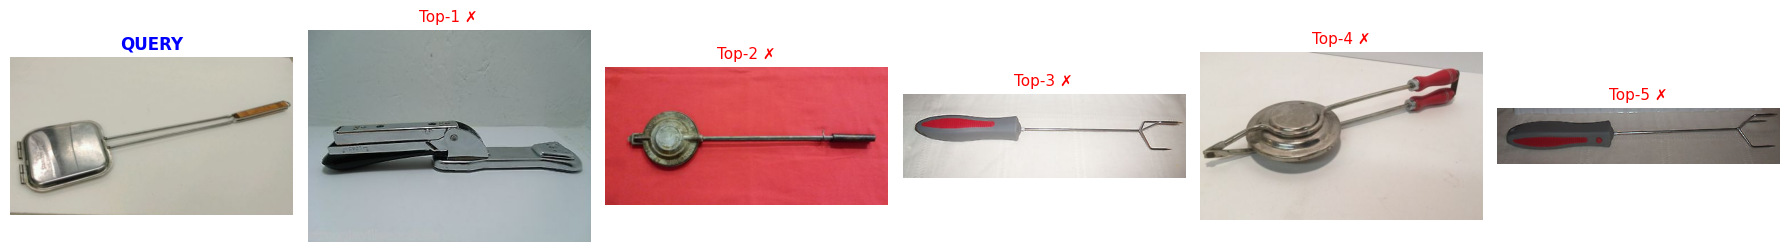

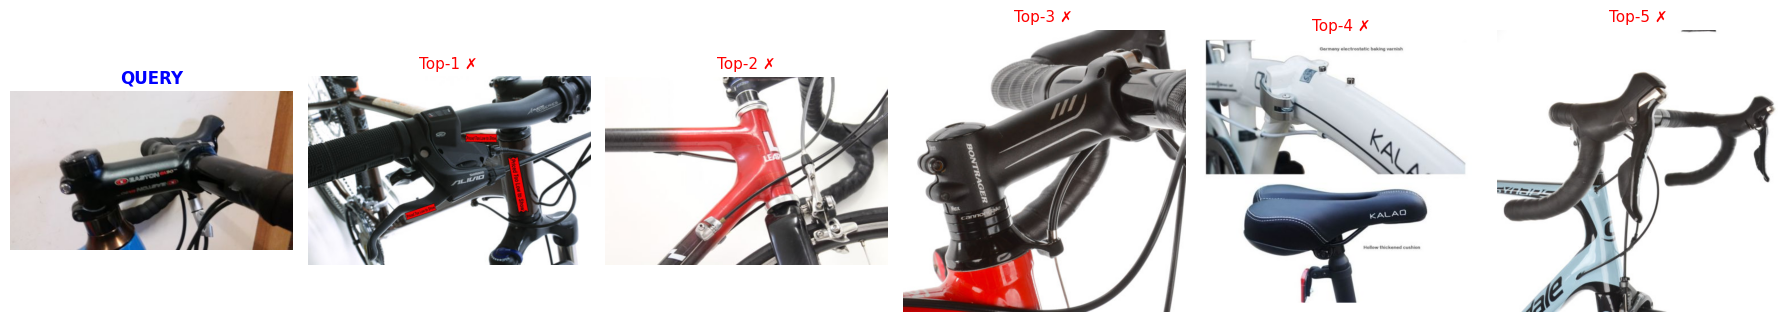

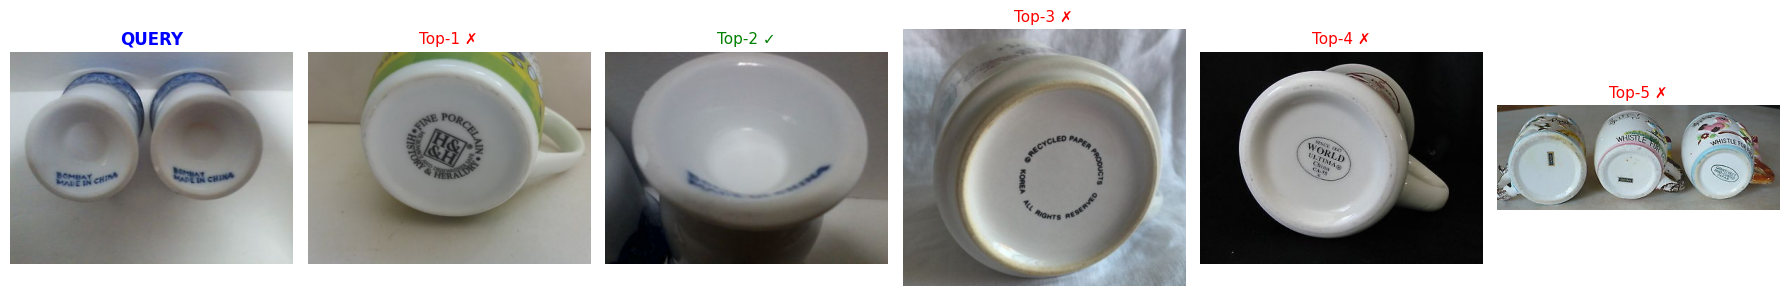

In [16]:
import matplotlib.pyplot as plt
import random

def visualize_retrieval(query_idx, test_emb, test_df, data_path, top_k=5):
    test_norm  = normalize(test_emb)
    query_emb  = test_norm[query_idx:query_idx+1]
    sims       = cosine_similarity(query_emb, test_norm)[0]
    sims[query_idx] = -1  # exclude self
    top_k_idx  = np.argsort(-sims)[:top_k]
    
    fig, axes = plt.subplots(1, top_k+1, figsize=(18, 4))
    
    query_path = os.path.join(data_path, test_df.iloc[query_idx]['path'])
    query_img  = Image.open(query_path).convert('RGB')
    axes[0].imshow(query_img)
    axes[0].set_title("QUERY", fontsize=12, fontweight='bold', color='blue')
    axes[0].axis('off')
    
    for i, idx in enumerate(top_k_idx):
        img_path = os.path.join(data_path, test_df.iloc[idx]['path'])
        img      = Image.open(img_path).convert('RGB')
        axes[i+1].imshow(img)
        
        query_label     = test_df.iloc[query_idx]['class_id']
        retrieved_label = test_df.iloc[idx]['class_id']
        match = "✓" if query_label == retrieved_label else "✗"
        color = "green" if query_label == retrieved_label else "red"
        
        axes[i+1].set_title(f"Top-{i+1} {match}", fontsize=11, color=color)
        axes[i+1].axis('off')
    
    plt.tight_layout()
    plt.show()

# Run visualization
for _ in range(3):
    idx = random.randint(0, len(test_df)-1)
    visualize_retrieval(idx, test_embeddings, test_df, data_path)